# MARL-Gated RALA Vision Transformer (v2)

**Corrected Implementation** — Fixes relative to `ViT copy.ipynb`:
1. **Multi-agent**: single SharedActorCritic at ViT level, passed to every layer
2. **MARL gating** replaces RALA's α_j reweighting; keeps Hadamard product output gate
3. **State dilution** term Γ_τ in recurrent memory
4. **Proper PPO** with rollout buffer (old log_probs, actual ratio)
5. **Correct squashed Gaussian entropy** with Jacobian correction
6. **Per-token critic** values (not per-chunk)
7. **Fisher target** computed per-token (averaged over heads)

---

### Training Pipeline
- **Stage 1:** Pure Backbone Pre-training (Learn Spatial Geometry)
- **Stage 2:** Router Warm-up via Fisher Information (Frozen Backbone)
- **Stage 3:** End-to-End PPO Fine-Tuning (Budget Constraint)

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
from torchvision import transforms
from datasets import load_dataset
from einops import rearrange
from tqdm import tqdm
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

## 1. Dataset & Transformations
**Run this cell once** — the dataset stays in memory for all subsequent cells.

In [64]:
transform = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class HFImageNetDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        image = item['image']
        label = item['label']
        if image.mode != 'RGB':
            image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading ImageNet-100 from Hugging Face...")
hf_train = load_dataset("clane9/imagenet-100", split="train")
hf_val = load_dataset("clane9/imagenet-100", split="validation")

batch_size = 64
train_dataset = HFImageNetDataset(hf_train, transform=transform)
val_dataset = HFImageNetDataset(hf_val, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=0, pin_memory=True if torch.cuda.is_available() else False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")
print(f"Batch size: {batch_size} | Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Using device: cuda
Loading ImageNet-100 from Hugging Face...


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Train: 126689 images | Val: 5000 images
Batch size: 64 | Train batches: 1980 | Val batches: 79


## 2. Architecture Definitions

In [65]:
class SharedActorCritic(nn.Module):
    """
    Shared Actor-Critic for the swarm of N agents.
    
    - Shared across ALL layers (parameter sharing as described in the paper).
    - Each token is an independent agent; the AC processes them all in parallel.
    - The actor outputs a squashed Gaussian scalar weight w ∈ (0,1) per token.
    - The critic outputs a per-token value estimate.
    """
    def __init__(self, d_model: int):
        super().__init__()
        half = max(d_model // 2, 16)

        # Shared projection: s_{n,l} = Proj(x_{n,l})
        self.proj = nn.Linear(d_model, half)

        # Actor: produces μ and σ for the squashed Gaussian
        self.actor_mlp = nn.Sequential(nn.Linear(half, half), nn.ELU())
        self.mu_head = nn.Linear(half, 1)
        self.sigma_head = nn.Linear(half, 1)

        # Critic: per-token value estimate V_φ(s_{n,l})
        self.critic_mlp = nn.Sequential(
            nn.Linear(half, half), nn.ELU(), nn.Linear(half, 1)
        )

    def forward(self, local_features: torch.Tensor, deterministic: bool = False):
        """
        Args:
            local_features: (B, N, d_model) — token features at layer l
            deterministic: if True, use mean (no sampling)
        Returns:
            w:        (B, N)   — gating weights in (0, 1)
            log_prob: (B, N)   — Jacobian-corrected log probability (None if deterministic)
            value:    (B, N)   — per-token value estimate
            mu:       (B, N)   — actor mean (for entropy computation)
            sigma:    (B, N)   — actor std (for entropy computation)
        """
        # State observation for each agent
        s = self.proj(local_features)                       # (B, N, half)

        # Actor
        h_actor = self.actor_mlp(s)                         # (B, N, half)
        mu = self.mu_head(h_actor).squeeze(-1)              # (B, N)
        sigma = F.softplus(self.sigma_head(h_actor)).squeeze(-1) + 1e-5  # (B, N)

        # Critic — per-token value
        value = self.critic_mlp(s).squeeze(-1)              # (B, N)

        if deterministic:
            z = mu
            log_prob = None
        else:
            dist = Normal(mu, sigma)
            z = dist.rsample()                              # reparameterization trick
            log_prob = dist.log_prob(z)                     # (B, N)

        # Squash to (0, 1) via tanh
        # Apply temperature scaling to force sharpness and break the 0.5 saddle-point trap
        w_raw = torch.tanh(z * 5.0)
        w = (w_raw + 1.0) / 2.0                            # (B, N)

        # Jacobian correction for the log probability
        if not deterministic:
            # log|det(dw/dz)| = log((1 - tanh²(z))/2 + ε)
            # log|det(dw/dz)| with temperature factor
            jacobian = torch.log(5.0 * 0.5 * (1.0 - w_raw.pow(2)) + 1e-5)
            log_prob = log_prob - jacobian                  # (B, N)

        return w, log_prob, value, mu, sigma


class ChunkwiseRALAAttention(nn.Module):
    """
    Chunkwise Linear Attention with MARL gating.
    
    Based on RALA but replaces α_j reweighting with MARL agent weights:
    - κ(·) = ELU(·) + 1.0 kernel function
    - MARL gating: w_t from shared Actor-Critic replaces RALA's α_j
    - Output modulation: Y_i = φ(X_i) ⊙ (κ(Q_i) · S_t) — Hadamard product gate
    
    The router is NOT internal — weights are passed from outside.
    """
    def __init__(self, d_model: int, head: int = 8, chunk_size: int = 16,
                 gamma: float = 0.1, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.head = head
        self.chunk_size = chunk_size
        self.gamma = gamma
        self.d_k = d_model // head

        # QKV projection
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        # Output gate: φ(X) for Hadamard product modulation
        self.w_o_gate = nn.Linear(d_model, d_model)

        # Output projection
        self.w_o_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, w_gating, use_dilution=False):
        """
        Args:
            x:            (B, N, d_model)
            w_gating:     (B, N) — per-token gating weights from the shared AC
            use_dilution: bool — enable state dilution Γ_τ (Phase 2/3)
        Returns:
            out:  (B, N, d_model) — attention output
            phi_k: for Fisher info computation (gradients flow through here)
        """
        b, n, d = x.shape
        T = n // self.chunk_size
        C = self.chunk_size

        # --- Linear projections ---
        q = rearrange(self.w_q(x), 'b (T C) (h dk) -> b T h C dk',
                       T=T, C=C, h=self.head)
        k = rearrange(self.w_k(x), 'b (T C) (h dk) -> b T h C dk',
                       T=T, C=C, h=self.head)
        v = rearrange(self.w_v(x), 'b (T C) (h dk) -> b T h C dk',
                       T=T, C=C, h=self.head)

        # Scaling
        q = q * (self.d_k ** -0.25)
        k = k * (self.d_k ** -0.25)

        # --- Kernel function: κ(·) = ELU(·) + 1 ---
        phi_q = F.elu(q) + 1.0  # (B, T, h, C, dk)
        phi_k = F.elu(k) + 1.0  # (B, T, h, C, dk)

        # --- Apply MARL gating directly to φ(K) ---
        # MARL agents replace RALA's α_j: each agent's weight gates its token's key
        # w_gating: (B, N) -> reshape to (B, T, C) -> expand to (B, T, 1, C, 1)
        w_chunks = rearrange(w_gating, 'b (T C) -> b T C', T=T, C=C)
        w_expanded = w_chunks.unsqueeze(2).unsqueeze(-1)  # (B, T, 1, C, 1)
        k_gated = w_expanded * phi_k                      # (B, T, h, C, dk)

        # --- Chunk-level KV computation ---
        k_gated_f32 = k_gated.to(torch.float32)
        v_f32 = v.to(torch.float32)
        KV_chunks = torch.matmul(k_gated_f32.transpose(-2, -1), v_f32)  # (B,T,h,dk,dk)
        Z_chunks = k_gated_f32.sum(dim=-2)                               # (B,T,h,dk)

        # --- Chunk-level average gating weight w̄_t ---
        w_bar = w_chunks.mean(dim=-1)  # (B, T)

        # --- Sequential recurrence ---
        outputs = []
        S = torch.zeros(b, self.head, self.d_k, self.d_k,
                        device=x.device, dtype=torch.float32)
        Z = torch.zeros(b, self.head, self.d_k,
                        device=x.device, dtype=torch.float32)

        for t in range(T):
            # Decay: 1 - γ(1 - w̄_t)
            decay_factor = 1.0 - (self.gamma * (1.0 - w_bar[:, t]))
            decay_S = decay_factor.view(b, 1, 1, 1)
            decay_Z = decay_factor.view(b, 1, 1)

            # State dilution term Γ_τ (Eq. 11 from approach.tex)
            if use_dilution and t > 0:
                dilution_scale = self.gamma * (1.0 - w_bar[:, t])  # (B,)
                gamma_tau = dilution_scale.view(b, 1, 1, 1) * S / max(t, 1)
                S = (S * decay_S) + KV_chunks[:, t] + gamma_tau
            else:
                S = (S * decay_S) + KV_chunks[:, t]

            Z = (Z * decay_Z) + Z_chunks[:, t]

            # Attention output for chunk t
            phi_q_t = phi_q[:, t].to(torch.float32)          # (B, h, C, dk)
            nom = torch.matmul(phi_q_t, S)                   # (B, h, C, dk)
            denom = (phi_q_t * Z.unsqueeze(-2)).sum(dim=-1, keepdim=True) + 1e-5

            out_t = nom / denom

            if self.training:
                out_t = self.dropout(out_t)

            out_t = torch.clamp(out_t, min=-65000.0, max=65000.0)
            outputs.append(out_t.to(q.dtype))

        out = torch.stack(outputs, dim=1)                    # (B, T, h, C, dk)
        out = rearrange(out, 'b T h C dk -> b (T C) (h dk)')

        # --- Output modulation: Y = φ(X) ⊙ attn_output ---
        gate = torch.sigmoid(self.w_o_gate(x))                # (B, N, d)
        out = out * gate

        out = self.w_o_proj(out)

        return out, phi_k


class PatchEmbedding(nn.Module):
    def __init__(self, image_size=144, patch_size=12, in_chans=3, embed_dim=256):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class EncoderBlock(nn.Module):
    """
    A single encoder block. The attention module does NOT own a router.
    The router (SharedActorCritic) lives at the ViT level.
    """
    def __init__(self, d_model, head, chunk_size):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = ChunkwiseRALAAttention(d_model, head=head, chunk_size=chunk_size)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, d_model * 4)

    def forward(self, x, w_gating, use_dilution=False):
        res = x
        x_normed = self.norm1(x)
        out, phi_k = self.attn(x_normed, w_gating, use_dilution)
        x = res + out
        x = x + self.mlp(self.norm2(x))
        return x, phi_k


class ViT(nn.Module):
    """
    MARL-Gated RALA ViT.
    
    Key difference from v1: a SINGLE SharedActorCritic module is shared
    across all layers. At each layer, every token acts as an independent
    agent making its own gating decision via this shared policy.
    """
    def __init__(self, image_size=144, patch_size=12, num_classes=100,
                 d_model=256, depth=6, head=8, chunk_size=16):
        super().__init__()
        self.depth = depth
        self.patch_embed = PatchEmbedding(image_size, patch_size, 3, d_model)
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.patch_embed.num_patches, d_model))
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, head, chunk_size) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        # Single shared Actor-Critic for ALL layers (swarm with shared params)
        self.router = SharedActorCritic(d_model)

    def forward(self, x, deterministic=False, phase1=False, use_dilution=False):
        x = self.patch_embed(x) + self.pos_embed  # (B, N, d)

        w_list, log_prob_list, value_list, mu_list, sigma_list, kt_list = \
            [], [], [], [], [], []

        for block in self.blocks:
            # Each layer: the shared AC evaluates all N tokens (N agents)
            w, log_prob, value, mu, sigma = self.router(x, deterministic)

            if phase1:
                w_gating = torch.ones_like(w)
            else:
                w_gating = w

            x, phi_k = block(x, w_gating, use_dilution)

            w_list.append(w)
            log_prob_list.append(log_prob)
            value_list.append(value)
            mu_list.append(mu)
            sigma_list.append(sigma)
            kt_list.append(phi_k)

        x = self.norm(x)
        logits = self.head(x.mean(dim=1))  # (B, num_classes)

        has_log_prob = log_prob_list[0] is not None

        return {
            'logits': logits,
            'w_t': torch.stack(w_list, dim=1),           # (B, L, N)
            'log_probs': torch.stack(log_prob_list, dim=1) if has_log_prob else None,
            'values': torch.stack(value_list, dim=1),     # (B, L, N)
            'mu': torch.stack(mu_list, dim=1),            # (B, L, N)
            'sigma': torch.stack(sigma_list, dim=1),      # (B, L, N)
            'k_t': kt_list                                # list of (B,T,h,C,dk)
        }

## 3. Evaluation & Sanity Check

In [66]:
@torch.no_grad()
def evaluate(model, val_loader, device, phase_name, epoch):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    print(f"\n--- Running Validation ({phase_name} | Epoch {epoch+1}) ---")
    for images, labels in tqdm(val_loader, desc="Evaluating", leave=False):
        images, labels = images.to(device), labels.to(device)

        with torch.autocast(device_type=device.type):
            outputs = model(images, deterministic=True)
            logits = outputs['logits']
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total * 100.0
    print(f"Validation: Loss={avg_loss:.4f} | Accuracy={accuracy:.2f}%\n")
    model.train()


def sanity_check_overfit(model, train_loader, device, epochs=50):
    print("\n--- Pre-Flight Check: Single-Batch Overfit ---")
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')

    images, labels = next(iter(train_loader))
    images, labels = images.to(device), labels.to(device)

    loop = tqdm(range(epochs), desc="Overfitting Single Batch")
    for _ in loop:
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type):
            outputs = model(images, deterministic=True)
            logits = outputs['logits']
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = logits.argmax(dim=-1)
        acc = (preds == labels).float().mean().item() * 100.0
        loop.set_postfix(Loss=f"{loss.item():.4f}", Acc=f"{acc:.1f}%")

## 4. Training Stage 1: Pure Backbone Pre-training

In [5]:
def train_stage_1_backbone(model, train_loader, val_loader, epochs, device):
    """Phase 1: Train backbone with w=1.0 (no gating). Router params frozen."""
    print("\n--- Starting Stage 1: Pure Backbone Pre-training ---")
    model.train()

    backbone_params = [p for n, p in model.named_parameters() if 'router' not in n]
    optimizer = optim.AdamW(backbone_params, lr=3e-4)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')

    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"Stage 1 Epoch [{epoch+1}/{epochs}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.autocast(device_type=device.type):
                outputs = model(images, deterministic=True, phase1=True)
                logits = outputs['logits']
                loss = criterion(logits, labels)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(backbone_params, max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            preds = logits.argmax(dim=-1)
            acc = (preds == labels).float().mean().item() * 100
            loop.set_postfix(CE=loss.item(), Acc=f"{acc:.1f}%")

        if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
            evaluate(model, val_loader, device, "Stage 1", epoch)

## 5. Training Stage 2: Router Warm-up via Fisher Information

In [6]:
def train_stage_2_router(model, train_loader, val_loader, epochs, device):
    """
    Phase 2: Supervised warm-up of the shared Actor-Critic using Fisher Information.
    
    - Fisher info is per-token (averaged over heads), not per-head
    - Critic target is sum of all Fisher saliencies (matching paper Eq. 8)
    - Backbone is frozen
    """
    print("\n--- Starting Stage 2: MARL Router Warm-up (Frozen Backbone) ---")
    model.train()

    router_params = [p for n, p in model.named_parameters() if 'router' in n]
    optimizer_router = optim.AdamW(router_params, lr=1e-4)
    criterion_ce = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')

    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"Stage 2 Epoch [{epoch+1}/{epochs}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            with torch.autocast(device_type=device.type):
                outputs = model(images, deterministic=True, phase1=True)
                logits = outputs['logits']
                k_t_list = outputs['k_t']        # list of (B,T,h,C,dk)
                w_pred = outputs['w_t']           # (B, L, N)
                v_pred = outputs['values']        # (B, L, N)
                loss_ce = criterion_ce(logits, labels)

            if torch.isnan(loss_ce) or torch.isinf(loss_ce):
                optimizer_router.zero_grad()
                continue

            # 1. Hook gradients of phi_k for Fisher info
            k_t_grads = [None] * len(k_t_list)
            hooks = []
            for i, k_t in enumerate(k_t_list):
                def make_hook(idx):
                    return lambda grad: k_t_grads.__setitem__(idx, grad.clone())
                if k_t.requires_grad:
                    hooks.append(k_t.register_hook(make_hook(i)))

            model.zero_grad()

            # 2. Backward to compute Fisher gradients
            scaler.scale(loss_ce).backward(retain_graph=True)

            for h in hooks:
                h.remove()

            for i in range(len(k_t_grads)):
                if k_t_grads[i] is None:
                    k_t_grads[i] = torch.zeros_like(k_t_list[i])

            # 3. Compute per-token Fisher targets
            fisher_targets_actor = []  # list of (B, N)
            for i in range(len(k_t_grads)):
                grad = k_t_grads[i].to(torch.float32) / scaler.get_scale()
                grad = torch.nan_to_num(grad, nan=0.0, posinf=100.0, neginf=-100.0)
                # Fisher info: E[grad²], per-token
                fisher_raw = (grad ** 2).mean(dim=(2, 4))  # (B, T, C) - avg over heads & dk
                fisher_log = torch.log(fisher_raw + 1e-8)

                # Normalize to [0, 1] per sample
                f_min = fisher_log.amin(dim=(1, 2), keepdim=True)
                f_max = fisher_log.amax(dim=(1, 2), keepdim=True)
                fisher_norm = (fisher_log - f_min) / (f_max - f_min + 1e-8)  # (B, T, C)

                # Flatten to (B, N)
                fisher_flat = rearrange(fisher_norm, 'b T C -> b (T C)')
                fisher_targets_actor.append(fisher_flat)

            # Stack: (B, L, N)
            fisher_target_actor = torch.stack(fisher_targets_actor, dim=1)

            # Critic target: sum of all Fisher saliencies across tokens (per layer)
            fisher_target_critic = fisher_target_actor.sum(dim=-1, keepdim=True)  # (B, L, 1)
            fisher_target_critic = fisher_target_critic.expand_as(v_pred)         # (B, L, N)

            # 4. Compute Router Loss
            with torch.autocast(device_type=device.type):
                loss_actor = F.mse_loss(w_pred, fisher_target_actor.detach())
                loss_critic = F.mse_loss(v_pred, fisher_target_critic.detach())
                loss_router = loss_actor + loss_critic

            optimizer_router.zero_grad()

            # 5. Backward and step
            scaler.scale(loss_router).backward()
            torch.nn.utils.clip_grad_norm_(router_params, max_norm=1.0)
            scaler.step(optimizer_router)
            scaler.update()

            preds = logits.argmax(dim=-1)
            acc = (preds == labels).float().mean().item() * 100
            loop.set_postfix(CE=loss_ce.item(), Router=loss_router.item(),
                             Acc=f"{acc:.1f}%")

        if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
            evaluate(model, val_loader, device, "Stage 2", epoch)

## 6. Training Stage 3: End-to-End PPO Fine-tuning

In [67]:
def compute_squashed_entropy(sigma, w_raw_samples=None):
    """
    Compute Jacobian-corrected entropy for the squashed Gaussian.
    """
    gaussian_entropy = 0.5 * torch.log(2 * math.pi * math.e * sigma.pow(2) + 1e-8)

    if w_raw_samples is not None:
        tanh_z = torch.tanh(w_raw_samples)
        jacobian_correction = torch.log(5.0 * 0.5 * (1.0 - tanh_z.pow(2)) + 1e-5)
        return (gaussian_entropy + jacobian_correction).mean()
    else:
        return gaussian_entropy.mean()

def compute_bimodal_sparsity(w_t):
    """
    Bimodal sparsity penalty: w * (1 - w)
    Pushes weights towards 0 or 1.
    """
    return (w_t * (1.0 - w_t)).mean()

def train_stage_3_ppo(model, train_loader, val_loader, epochs, device,
                      lambda_budget=2.0, lambda_sparse=1.0, ppo_epochs=3,
                      clip_eps=0.2, entropy_coeff=0.01):
    """
    Phase 3: End-to-end PPO fine-tuning.
    
    Reward = -CE_loss - lambda_budget * mean(w_t) - lambda_sparse * w(1-w)
    
    The budget penalty pushes retention DOWN.
    The bimodal sparsity pushes weights to be BINARY (0 or 1).
    """
    print("\n--- Starting Stage 3: End-to-End MARL PPO Fine-tuning ---")
    print(f"    lambda_budget={lambda_budget}, lambda_sparse={lambda_sparse}, ppo_epochs={ppo_epochs}")
    print(f"    clip_eps={clip_eps}, entropy_coeff={entropy_coeff}")
    model.train()

    optimizer = optim.AdamW(model.parameters(), lr=1e-5)
    criterion_ce_none = nn.CrossEntropyLoss(reduction='none')
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')

    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"Stage 3 Epoch [{epoch+1}/{epochs}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            # ===== STEP 1: Collect rollout (old policy) =====
            with torch.no_grad():
                with torch.autocast(device_type=device.type):
                    old_outputs = model(images, deterministic=False, use_dilution=True)
                    old_log_probs = old_outputs['log_probs'].detach()  # (B, L, N)
                    old_values = old_outputs['values'].detach()        # (B, L, N)
                    old_w_t = old_outputs['w_t'].detach()              # (B, L, N)

                    # Terminal reward
                    logits_old = old_outputs['logits']
                    ce_old = criterion_ce_none(logits_old, labels)     # (B,)
                    task_reward = -ce_old                              # (B,)
                    
                    budget_cost = old_w_t.mean(dim=(1, 2))            # (B,)
                    sparsity_penalty = (old_w_t * (1.0 - old_w_t)).mean(dim=(1, 2)) # (B,)
                    
                    terminal_reward = task_reward - lambda_budget * budget_cost - lambda_sparse * sparsity_penalty  # (B,)

                    # Returns broadcasted to all layers/tokens
                    returns = terminal_reward.view(-1, 1, 1).expand_as(old_values)

                    # GAE-style advantages
                    advantages = returns - old_values
                    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # ===== STEP 2: PPO policy update (K epochs) =====
            for k in range(ppo_epochs):
                optimizer.zero_grad()

                with torch.autocast(device_type=device.type):
                    new_outputs = model(images, deterministic=False, use_dilution=True)
                    new_logits = new_outputs['logits']
                    new_log_probs = new_outputs['log_probs']     # (B, L, N)
                    new_values = new_outputs['values']           # (B, L, N)
                    new_sigma = new_outputs['sigma']             # (B, L, N)
                    new_w_t = new_outputs['w_t']                 # (B, L, N)

                    # --- Classification loss ---
                    loss_ce = criterion_ce_none(new_logits, labels).mean()

                    # --- PPO policy loss ---
                    ratio = torch.exp(new_log_probs - old_log_probs)  # pi_new / pi_old
                    surr1 = ratio * advantages
                    surr2 = torch.clamp(ratio, 1.0 - clip_eps,
                                        1.0 + clip_eps) * advantages
                    policy_loss = -torch.min(surr1, surr2).mean()

                    # --- Value loss ---
                    value_loss = F.mse_loss(new_values, returns)

                    # --- Squashed Gaussian entropy bonus ---
                    entropy = compute_squashed_entropy(new_sigma)
                    entropy_bonus = entropy_coeff * entropy

                    # --- Direct budget minimization and bimodal sparsity ---
                    budget_loss = lambda_budget * new_w_t.mean()
                    sparse_loss = lambda_sparse * compute_bimodal_sparsity(new_w_t)

                    # --- Total loss ---
                    loss_ppo = (policy_loss
                                + 0.5 * value_loss
                                - entropy_bonus)
                    
                    total_loss = loss_ce + loss_ppo + budget_loss + sparse_loss

                scaler.scale(total_loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            preds = new_logits.argmax(dim=-1)
            acc = (preds == labels).float().mean().item() * 100
            loop.set_postfix(
                CE=f"{loss_ce.item():.3f}",
                P=f"{policy_loss.item():.3f}",
                Bdgt=f"{budget_loss.item():.3f}",
                Sprs=f"{sparse_loss.item():.3f}",
                R=f"{new_w_t.mean().item()*100:.1f}%",
                Acc=f"{acc:.1f}%"
            )

        # Save checkpoint every epoch
        import os
        os.makedirs(f'checkpoints/{lambda_budget},{lambda_sparse}', exist_ok=True)
        ckpt_path = f'checkpoints/{lambda_budget},{lambda_sparse}/vit_v2_stage_3_epoch{epoch+1}.pth'
        torch.save(model.state_dict(), ckpt_path)
        print(f'    [SAVED] {ckpt_path}')

        evaluate(model, val_loader, device, "Stage 3", epoch)
        visualize_routing_decisions(ckpt_path, val_dataset, device, image_index= 4900)


## 7. Visualizer

In [68]:
@torch.no_grad()
def visualize_routing_decisions(model_path, dataset, device, image_index=0):
    print("Loading trained weights...")
    model = ViT(
        image_size=144, patch_size=12, num_classes=100,
        d_model=256, depth=16, head=8, chunk_size=16
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device,
                                     weights_only=True))
    model.eval()

    image_tensor, label_idx = dataset[image_index]
    image_batch = image_tensor.unsqueeze(0).to(device)

    outputs = model(image_batch, deterministic=True)
    w_t = outputs['w_t']   # (1, L, N)
    logits = outputs['logits']

    pred_idx = logits.argmax(dim=-1).item()

    try:
        hf_features = dataset.hf_split.features['label']
        true_name = hf_features.int2str(label_idx)
        pred_name = hf_features.int2str(pred_idx)
    except:
        true_name = f"Class {label_idx}"
        pred_name = f"Class {pred_idx}"

    # Average across layers: (1, L, N) -> (N,)
    routing_weights = w_t[0].mean(dim=0).cpu().numpy()
    grid_size = int(math.sqrt(len(routing_weights)))
    heatmap = routing_weights.reshape(grid_size, grid_size)

    # Denormalize
    img_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    heatmap_resized = cv2.resize(heatmap, (144, 144),
                                  interpolation=cv2.INTER_CUBIC)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    title_color = "green" if label_idx == pred_idx else "red"
    axes[0].imshow(img_np)
    axes[0].set_title(f"True: {true_name}\nPred: {pred_name}",
                      color=title_color, fontweight='bold')
    axes[0].axis('off')

    im = axes[1].imshow(heatmap_resized, cmap='jet', alpha=0.8, vmin=0, vmax=1)
    axes[1].set_title("MARL Agent Routing Map (w_t)")
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(img_np)
    axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.4, vmin=0, vmax=1)
    axes[2].set_title("Overlay (High value = Retained)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## 8. Initialize Model & Sanity Check
Re-run this cell to reinitialize a fresh model.

In [18]:
model = ViT(
    image_size=144, patch_size=12, num_classes=100,
    d_model=256, depth=16, head=8, chunk_size=16
).to(device)

print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Router params: {sum(p.numel() for n, p in model.named_parameters() if 'router' in n):,}")

sanity_check_overfit(model, train_loader, device, epochs=50)

Total params: 13,929,063
Router params: 66,307

--- Pre-Flight Check: Single-Batch Overfit ---


Overfitting Single Batch: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s, Acc=100.0%, Loss=0.0207]


## 9. Stage 1: Backbone Pre-training
Re-initialize model before running this.

In [19]:
model = ViT(
    image_size=144, patch_size=12, num_classes=100,
    d_model=256, depth=16, head=8, chunk_size=16
).to(device)

train_stage_1_backbone(model, train_loader, val_loader, epochs=20, device=device)
torch.save(model.state_dict(), "vit_v2_stage_1_backbone.pth")
print("✅ Stage 1 checkpoint saved.")


--- Starting Stage 1: Pure Backbone Pre-training ---


Stage 1 Epoch [5/20]: 100%|██████████| 1980/1980 [29:16<00:00,  1.13it/s, Acc=15.2%, CE=3.12]



--- Running Validation (Stage 1 | Epoch 5) ---


Validation: Loss=2.9936 | Accuracy=25.52%



Stage 1 Epoch [10/20]: 100%|██████████| 1980/1980 [28:39<00:00,  1.15it/s, Acc=24.2%, CE=2.69]


...


--- Running Validation (Stage 1 | Epoch 15) ---


Validation: Loss=2.3322 | Accuracy=39.76%



Stage 1 Epoch [20/20]: 100%|██████████| 1980/1980 [28:28<00:00,  1.16it/s, Acc=60.6%, CE=1.29]



--- Running Validation (Stage 1 | Epoch 20) ---


Validation: Loss=2.1320 | Accuracy=45.14%

✅ Stage 1 checkpoint saved.


## 10. Stage 2: Router Warm-up (Fisher Information)
Continues from Stage 1 checkpoint.

In [61]:
# Load Stage 1 weights if starting fresh
# model.load_state_dict(torch.load("vit_v2_stage_1_backbone.pth", map_location=device, weights_only=True))

train_stage_2_router(model, train_loader, val_loader, epochs=10, device=device)
torch.save(model.state_dict(), "vit_v2_stage_2_router.pth")
print("✅ Stage 2 checkpoint saved.")


--- Starting Stage 2: MARL Router Warm-up (Frozen Backbone) ---


Stage 2 Epoch [1/10]:   0%|          | 0/1980 [00:01<?, ?it/s]


KeyboardInterrupt: 

## 11. Stage 3: PPO Fine-tuning
Continues from Stage 2 checkpoint.


--- Starting Stage 3: End-to-End MARL PPO Fine-tuning ---
    lambda_budget=0.1, lambda_sparse=1.0, ppo_epochs=1
    clip_eps=0.2, entropy_coeff=0.01


Stage 3 Epoch [1/10]: 100%|██████████| 1980/1980 [46:36<00:00,  1.41s/it, Acc=75.8%, Bdgt=0.049, CE=0.867, P=0.041, R=49.1%, Sprs=0.167]


    [SAVED] checkpoints/0.1,1.0/vit_v2_stage_3_epoch1.pth

--- Running Validation (Stage 3 | Epoch 1) ---


Validation: Loss=1.9681 | Accuracy=49.12%

Loading trained weights...


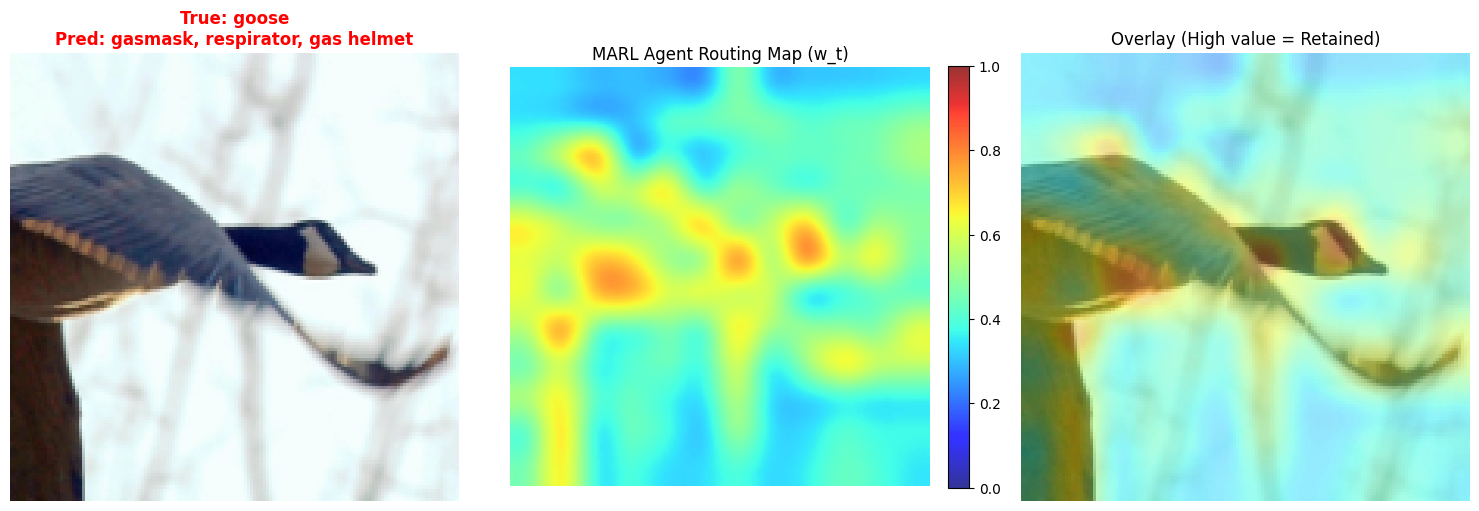

Stage 3 Epoch [2/10]: 100%|██████████| 1980/1980 [45:59<00:00,  1.39s/it, Acc=63.6%, Bdgt=0.050, CE=1.238, P=0.026, R=50.0%, Sprs=0.166]


    [SAVED] checkpoints/0.1,1.0/vit_v2_stage_3_epoch2.pth

--- Running Validation (Stage 3 | Epoch 2) ---


Validation: Loss=1.9708 | Accuracy=50.16%

Loading trained weights...


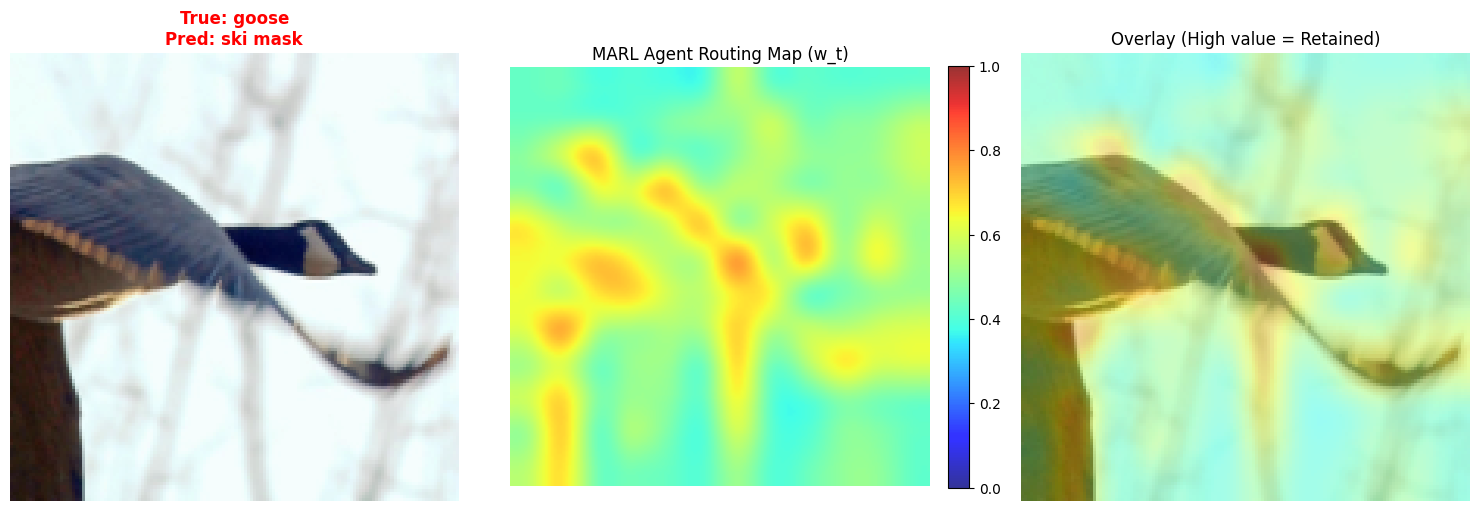

Stage 3 Epoch [3/10]: 100%|██████████| 1980/1980 [46:05<00:00,  1.40s/it, Acc=63.6%, Bdgt=0.051, CE=1.635, P=0.023, R=50.7%, Sprs=0.166]


    [SAVED] checkpoints/0.1,1.0/vit_v2_stage_3_epoch3.pth

--- Running Validation (Stage 3 | Epoch 3) ---


Validation: Loss=1.9622 | Accuracy=49.52%

Loading trained weights...


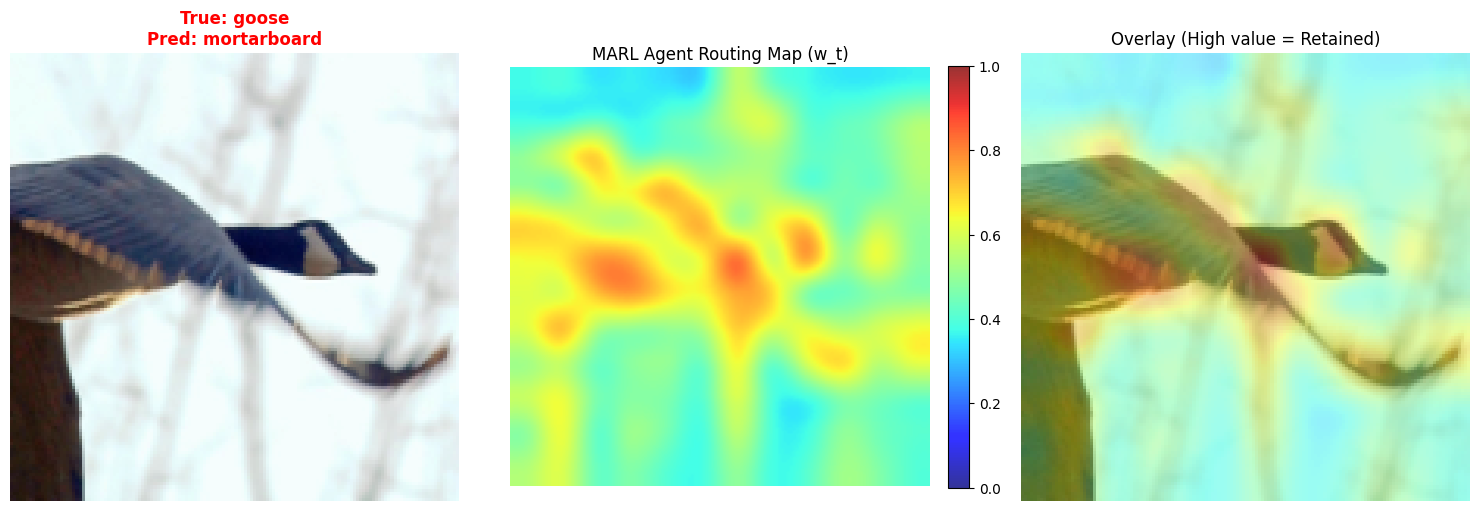

Stage 3 Epoch [4/10]: 100%|██████████| 1980/1980 [46:14<00:00,  1.40s/it, Acc=66.7%, Bdgt=0.051, CE=0.951, P=0.026, R=50.6%, Sprs=0.165]


    [SAVED] checkpoints/0.1,1.0/vit_v2_stage_3_epoch4.pth

--- Running Validation (Stage 3 | Epoch 4) ---


Validation: Loss=1.9860 | Accuracy=49.12%

Loading trained weights...


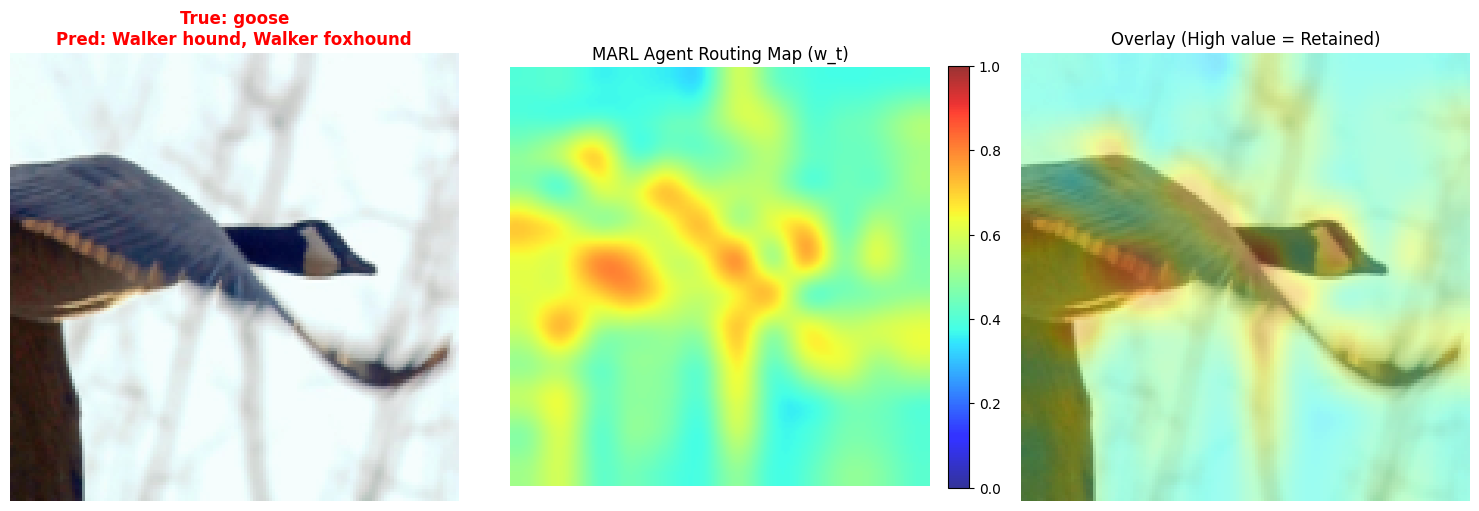

Stage 3 Epoch [5/10]: 100%|██████████| 1980/1980 [48:20<00:00,  1.47s/it, Acc=72.7%, Bdgt=0.051, CE=1.128, P=0.028, R=50.8%, Sprs=0.165]


    [SAVED] checkpoints/0.1,1.0/vit_v2_stage_3_epoch5.pth

--- Running Validation (Stage 3 | Epoch 5) ---


Validation: Loss=1.9815 | Accuracy=49.10%

Loading trained weights...


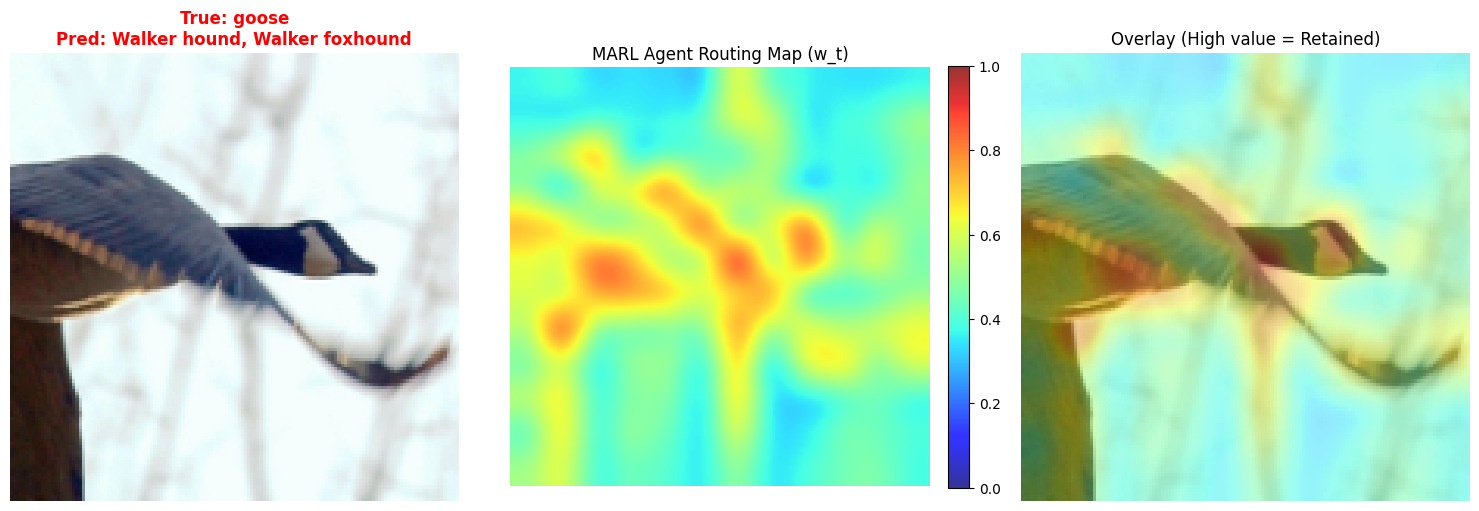

Stage 3 Epoch [6/10]: 100%|██████████| 1980/1980 [48:27<00:00,  1.47s/it, Acc=69.7%, Bdgt=0.051, CE=0.996, P=0.021, R=51.0%, Sprs=0.165]


    [SAVED] checkpoints/0.1,1.0/vit_v2_stage_3_epoch6.pth

--- Running Validation (Stage 3 | Epoch 6) ---


Validation: Loss=1.9832 | Accuracy=49.98%

Loading trained weights...


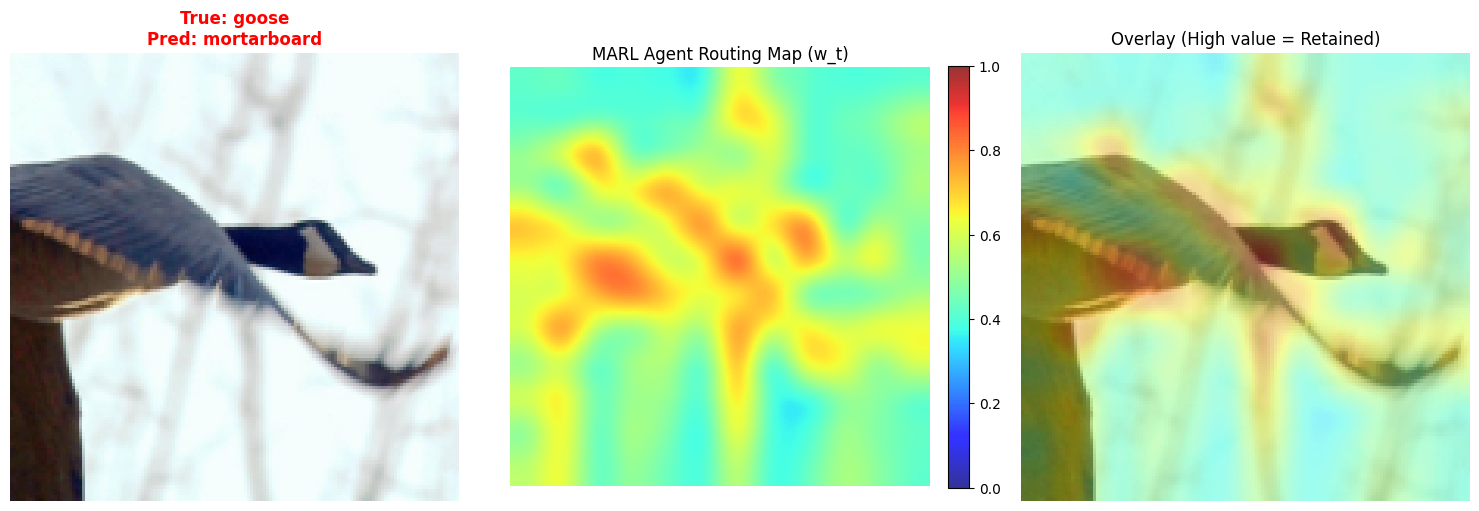

Stage 3 Epoch [7/10]: 100%|██████████| 1980/1980 [48:26<00:00,  1.47s/it, Acc=78.8%, Bdgt=0.051, CE=0.789, P=0.017, R=51.0%, Sprs=0.165]


    [SAVED] checkpoints/0.1,1.0/vit_v2_stage_3_epoch7.pth

--- Running Validation (Stage 3 | Epoch 7) ---


Validation: Loss=2.0004 | Accuracy=49.34%

Loading trained weights...


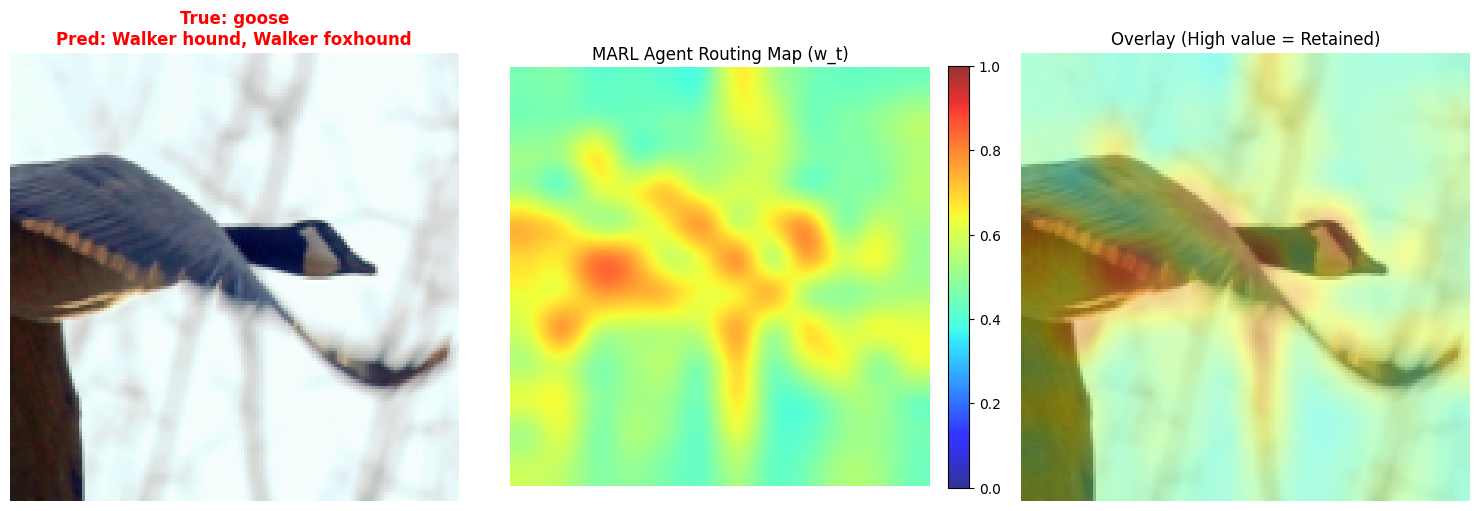

Stage 3 Epoch [8/10]:   0%|          | 8/1980 [00:12<50:16,  1.53s/it, Acc=76.6%, Bdgt=0.051, CE=0.873, P=0.023, R=51.1%, Sprs=0.164]


KeyboardInterrupt: 

In [70]:
# Load Stage 2 weights if starting fresh
model.load_state_dict(torch.load("checkpoints/2.0,1.0/vit_v2_stage_3_epoch1.pth", map_location=device, weights_only=True))

train_stage_3_ppo(model, train_loader, val_loader, epochs=10, device=device, ppo_epochs=1,lambda_budget=0.1)
torch.save(model.state_dict(), "vit_v2_stage_3_final.pth")
print("✅ Stage 3 checkpoint saved.")

## 12. Visualization

Loading trained weights...


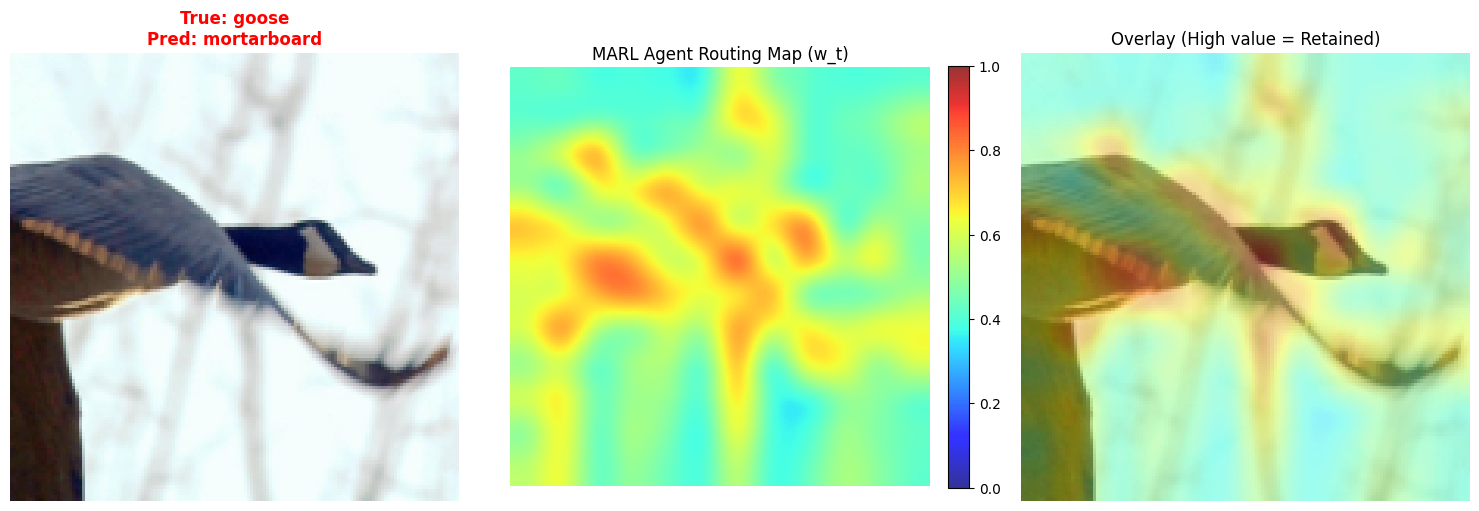

In [91]:
visualize_routing_decisions("checkpoints/0.1,1.0/vit_v2_stage_3_epoch6.pth", val_dataset, device, image_index= 4900)

## Part 4: Transfer Learning on CIFAR-10\n
Here we will verify the trained ViT features by completely freezing the backbone and learning a simple linear projection head on the CIFAR-10 dataset.

In [96]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from datasets import load_dataset

# 1. Same transforms as before (resizing 32x32 to 144x144)
transform_train = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform_test = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# 2. Custom Dataset wrapper for Hugging Face CIFAR-10
class HFCifarDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        image = item['img']  # CIFAR uses 'img' instead of 'image'
        label = item['label']
        
        if image.mode != 'RGB':
            image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

print("Downloading CIFAR-10 rapidly via Hugging Face...")
# 3. Load the dataset (this will take seconds instead of minutes/hours)
hf_cifar_train = load_dataset("cifar10", split="train")
hf_cifar_val = load_dataset("cifar10", split="test") # CIFAR uses 'test'

# 4. Wrap and create DataLoaders
cifar_train = HFCifarDataset(hf_cifar_train, transform=transform_train)
cifar_val = HFCifarDataset(hf_cifar_val, transform=transform_test)

cifar_train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True, num_workers=0)
cifar_val_loader = DataLoader(cifar_val, batch_size=128, shuffle=False, num_workers=0)

print(f"CIFAR-10 loaded. Train: {len(cifar_train)} | Val: {len(cifar_val)}")

CIFAR-10 loaded. Train: 50000 | Val: 10000


In [97]:
import glob
import torch.nn as nn

# 1. Freeze all backbone parameters
for param in model.parameters():
    param.requires_grad = False

# 2. Replace the classification head for 10 classes
d_model = model.norm.normalized_shape[0] if hasattr(model, 'norm') else 256
model.head = nn.Linear(d_model, 10).to(device)

# Make sure only the new head requires gradients
for param in model.head.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"All backbone parameters frozen. Only the new classification head is trainable ({trainable_params:,} parameters).")

All backbone parameters frozen. Only the new classification head is trainable (2,570 parameters).


In [ ]:
import torch.optim as optim
from tqdm.auto import tqdm
import os

def finetune_cifar(model, train_loader, val_loader, epochs=5, device='cuda'):
    print("\n--- Starting Linear Probing on CIFAR-10 ---")
    optimizer = optim.AdamW(model.head.parameters(), lr=1e-3, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss()
    
    best_acc = 0.0
    os.makedirs('checkpoints_cifar', exist_ok=True)
    
    for epoch in range(epochs):
        model.train() # sets head to train
        loop = tqdm(train_loader, desc=f"CIFAR Epoch [{epoch+1}/{epochs}]")
        
        correct = 0
        total = 0
        
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda' if 'cuda' in str(device) else 'cpu'):
                outputs = model(images, deterministic=True, use_dilution=True)
                logits = outputs['logits']
                loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            loop.set_postfix(Loss=f"{loss.item():.4f}", Acc=f"{100.*correct/total:.1f}%")
            
        # Validation Loop
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.autocast(device_type='cuda' if 'cuda' in str(device) else 'cpu'):
                    outputs = model(images, deterministic=True, use_dilution=True)
                    loss = criterion(outputs['logits'], labels)
                    
                val_loss += loss.item()
                val_correct += (outputs['logits'].argmax(dim=-1) == labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = 100.*val_correct/val_total
        print(f"Epoch {epoch+1} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'checkpoints_cifar/best_cifar_head.pth')
            print("Saved new best checkpoint.")

# Start Finetuning
finetune_cifar(model, cifar_train_loader, cifar_val_loader, epochs=5, device=device)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

# 1. Load the best fine-tuned model
model.load_state_dict(torch.load('checkpoints_cifar/best_cifar_head.pth', map_location=device))
print("Loaded best CIFAR-10 model.")

CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Configure number of images to visualize
num_visualize = 5 

model.eval()
dataset_size = len(cifar_val)
indices = [random.randint(0, dataset_size - 1) for _ in range(num_visualize)]

images = torch.stack([cifar_val[i][0] for i in indices]).to(device)
labels = torch.tensor([cifar_val[i][1] for i in indices]).to(device)

with torch.no_grad():
    outputs = model(images, deterministic=True, use_dilution=True)
    preds = outputs['logits'].argmax(dim=-1)
    w_t = outputs['w_t'] # (B, L, N)

fig, axes = plt.subplots(num_visualize, 3, figsize=(15, 5 * num_visualize))
if num_visualize == 1:
    axes = [axes]

for i in range(num_visualize):
    # Convert to HWC format for plotting
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * 0.5 + 0.5 # denormalize
    img = np.clip(img, 0, 1)
    
    true_label = CIFAR_CLASSES[labels[i].item()]
    pred_label = CIFAR_CLASSES[preds[i].item()]
    
    # Get routing map from the last layer
    wt_map = w_t[i, -1].cpu().numpy()
    sz = int(np.sqrt(len(wt_map)))
    wt_map_2d = wt_map.reshape(sz, sz)
    
    # Resize precisely to the image dimension
    img_h, img_w = img.shape[:2]
    wt_map_resized = cv2.resize(wt_map_2d, (img_w, img_h), interpolation=cv2.INTER_NEAREST)
    
    ax = axes[i][0]
    ax.imshow(img)
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight="bold")
    ax.axis("off")
    
    ax = axes[i][1]
    im = ax.imshow(wt_map_resized, cmap='jet', vmin=0, vmax=1)
    ax.set_title("Final Layer Router Output")
    ax.axis("off")
    
    ax = axes[i][2]
    ax.imshow(img)
    ax.imshow(wt_map_resized, cmap='jet', alpha=0.5, vmin=0, vmax=1)
    ax.set_title("Routing Overlay")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
import time

def measure_inference_speed(model, data_loader, device='cuda', num_batches=20):
    print("\n--- Measuring Inference Speed ---")
    model.eval()
    
    # Warmup
    dummy_images, _ = next(iter(data_loader))
    dummy_images = dummy_images.to(device)
    with torch.no_grad():
        for _ in range(5):
            with torch.autocast(device_type='cuda' if 'cuda' in str(device) else 'cpu'):
                _ = model(dummy_images, deterministic=True, use_dilution=True)
    
    if 'cuda' in str(device):
        torch.cuda.synchronize()
        
    start_time = time.time()
    total_images = 0
    total_correct = 0
    
    batch_count = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.autocast(device_type='cuda' if 'cuda' in str(device) else 'cpu'):
                outputs = model(images, deterministic=True, use_dilution=True)
                preds = outputs['logits'].argmax(dim=-1)
                total_correct += (preds == labels).sum().item()
            
            total_images += images.size(0)
            batch_count += 1
            if batch_count >= num_batches:
                break
                
    if 'cuda' in str(device):
        torch.cuda.synchronize()
        
    end_time = time.time()
    total_time = end_time - start_time
    latency_ms = (total_time / total_images) * 1000.0
    fps = total_images / total_time
    
    print(f"Processed {total_images} images in {total_time:.3f} seconds")
    print(f"Batch Size: {dummy_images.size(0)}")
    print(f"Latency per image: {latency_ms:.2f} ms")
    print(f"Throughput: {fps:.2f} FPS")
    accuracy = 100.0 * total_correct / total_images
    print(f"Accuracy over {num_batches} batches: {accuracy:.2f}%")

# Run inference benchmark
measure_inference_speed(model, cifar_val_loader, device=device)


--- Measuring Inference Speed ---


KeyboardInterrupt: 

In [22]:
# Re-Initialize the original 100-class ViT architecture to measure on ImageNet100
model_imagenet = ViT(
    image_size=144, patch_size=12, num_classes=100,
    d_model=256, depth=16, head=8, chunk_size=16
).to(device)

# Load the specific checkpoint requested
ckpt_path = 'checkpoints/0.1,1.0/vit_v2_stage_3_epoch6.pth'
model_imagenet.load_state_dict(torch.load(ckpt_path, map_location=device))
print(f"Loaded un-modified ImageNet100 model from {ckpt_path}")

print("\n=== ImageNet100 Inference Benchmark (Full Validation Set) ===")
# Forced to measure over the full length of the dataset to get absolute true accuracy
measure_inference_speed(model_imagenet, val_loader, device=device, num_batches=len(val_loader))

Loaded un-modified ImageNet100 model from checkpoints/0.1,1.0/vit_v2_stage_3_epoch6.pth

=== ImageNet100 Inference Benchmark (Full Validation Set) ===

--- Measuring Inference Speed ---
Processed 5000 images in 38.830 seconds
Batch Size: 64
Latency per image: 7.77 ms
Throughput: 128.77 FPS
Accuracy over 79 batches: 48.90%
